# Tidy Data Project


## Melting Data

In [358]:
import pandas as pd

# Creating the data frame with the data set 
df_fed = pd.read_csv('fed_rd_year&gdp.csv')

# Melting the data 
df_fed_melted = df_fed.melt(id_vars='department', var_name='year_gdp', value_name='rd_spending')

# Splitting the data to create 2 new columns
df_fed_melted[['year', 'gdp']] = df_fed_melted['year_gdp'].str.split('_gdp', expand = True)

df_fed_melted = df_fed_melted.drop(columns='year_gdp')

# This gets rid of the null values because the DHS didn't exist for several years, so now it has a 0 instead
df_fed_melted['rd_spending'] = df_fed_melted['rd_spending'].fillna(0)

print(df_fed_melted)


    department   rd_spending  year               gdp
0          DHS  0.000000e+00  1976   1790000000000.0
1          DOC  8.190000e+08  1976   1790000000000.0
2          DOD  3.569600e+10  1976   1790000000000.0
3          DOE  1.088200e+10  1976   1790000000000.0
4          DOT  1.142000e+09  1976   1790000000000.0
..         ...           ...   ...               ...
583        NIH  3.305200e+10  2017  19177000000000.0
584        NSF  6.040000e+09  2017  19177000000000.0
585      Other  1.553000e+09  2017  19177000000000.0
586       USDA  2.625000e+09  2017  19177000000000.0
587         VA  1.367000e+09  2017  19177000000000.0

[588 rows x 4 columns]


### Code Breakdown

I started by uploading my dataset. The dataset is of different federal agencies spending on research and development each year along with the overall GDP of the year. I loaded the dataset with pd.read_csv() into a dataframe. I used melt() to reshape the data into a long format from a wide format. The data was previously organized with many cilumns foor different years, but melting it made each row one department with one year and spending amount. I used str.split to seperate year_gdp because this had two different features in one. The year and GDP each needed their own columns. I used drop() to remove the missing values with 0. 


In [349]:
# I got this error "unsupported operand type(s) for /: 'float' and 'str'", when I tried to make the first visualization, so I used the dtypes function to check out the specific issue. 
print(df_fed_melted.dtypes)

# astype changes the data from object to integer/float
df_fed_melted['year'] = df_fed_melted['year'].astype(int)
df_fed_melted['gdp'] = df_fed_melted['gdp'].astype(float)


department      object
rd_spending    float64
year            object
gdp             object
dtype: object


### Code Breakdown

I fix a data type problem that caused an error. The error happened because Python was treating the GDP and year columns as objects (text) instead of numbers, so it could not divide values. First, I used dtypes to check the type of each column and confirm the issue. Then, I used astype() to convert the year column into integers, since years are whole numbers. I also used astype() to convert the gdp column into decimal numbers, since GDP values can include decimals. These changes make the data usable because  these columns as now numeric instead of text.


## Early Data Exploration

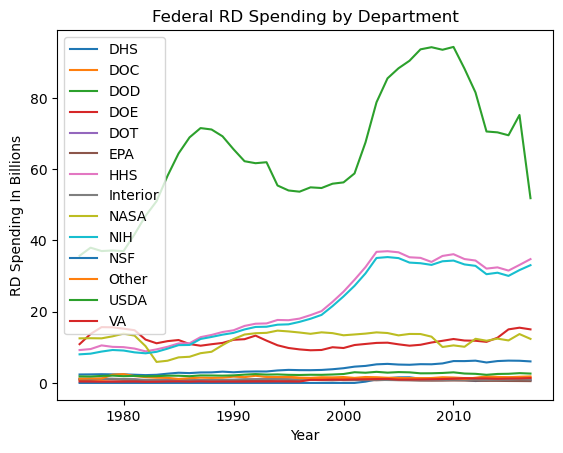

In [350]:
# Used to create the vizualizations
import matplotlib.pyplot as plt

# Create a new column that converts dollars to billions
df_fed_melted['rd_spending_billions'] = df_fed_melted['rd_spending'] / 1000000000


# Loops through every department 
# groupby() seperates the data by every department
for dept, dept_info in df_fed_melted.groupby('department'):
    plt.plot(dept_info['year'], dept_info['rd_spending_billions'], label=dept)
# Labels the axes
plt.xlabel('Year')
plt.ylabel('RD Spending In Billions')
plt.title('Federal RD Spending by Department')
# Creates the key
plt.legend()
plt.show()

### Code Breakdown

I create a line graph to show how spending changes over time for each department. I imported matplotlib.pyplot so I can make graphs. Then, I created a new column called rd_spending_billions by dividing the original spending values by a billion which makes the numbers easier to read and compare. I use groupby() to split the dataset into smaller pieces, one for each department. The loop goes through each department’s data, and plt.plot() draws a line using the year on the x-axis and spending on the y-axis. I also add labels with xlabel() and ylabel(), and a title with title() so the graph is clear. I created a kewy with plt.legend() to show which line belongs to each department, and plt.show() displays the graph. This graph was many for data exploration because I wanted to see if there were any trends I could spot right off the bat. However, by seeing that their are 14 different subjects, this graph made me consider making a smaller one to see more clear lines. The overlapping lines make it more difficult to focus, but it gives a big picture view of the dataset and helps identify which departments stand out enough to examine more carefully.

In [351]:
# Shows the highest OVERALL spending departments 
top_five_spending = (df_fed_melted.groupby('department')['rd_spending'].sum().sort_values(ascending=False).head(5))
print(top_five_spending)



department
DOD     2.716778e+12
HHS     9.364640e+11
NIH     8.869380e+11
NASA    5.098910e+11
DOE     4.991020e+11
Name: rd_spending, dtype: float64


### Code Breakdown: 

I identified which departments spend the most on research and development. I use groupby() to organize the data by department and then sum() to calculate the total spending for each one across all years. I use sort_values() to rank them from highest to lowest and head(5) to select the top five departments. 

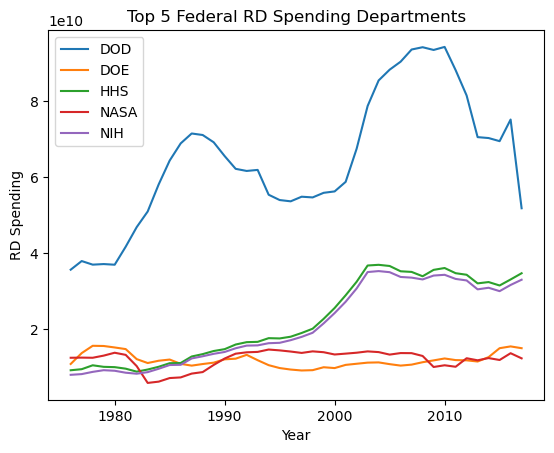

In [352]:
# Loops through every department 
# groupby() seperates the data by every department
for dept, dept_info in df_top_five.groupby('department'):
    plt.plot(dept_info['year'], dept_info['rd_spending'], label=dept)

# Labels axes
plt.xlabel('Year')
plt.ylabel('RD Spending')
plt.title('Top 5 Federal RD Spending Departments')

# Creates a key
plt.legend()
plt.show()

### Code Breakdown

This line graph was for me. I wouldn’t necessarily use it for presenting and sharing my data, but I wanted to make sure I understood the patterns of the dataset, and this helped me see how spending changes over time for the top five departments. In the code, I use groupby() to split the dataset so each department is handled separately. The loop goes through each department’s data and plt.plot() draws a line showing how its spending changes by year. I keep the original rd_spending values here so I can see the raw differences between departments. It is basically the same as the previous line graph, just with the top five spending agencies. This graph helped me quickly spot which departments spend the most and how their trends compare, which guided how I built my later visualizations.


## Data Visualizations

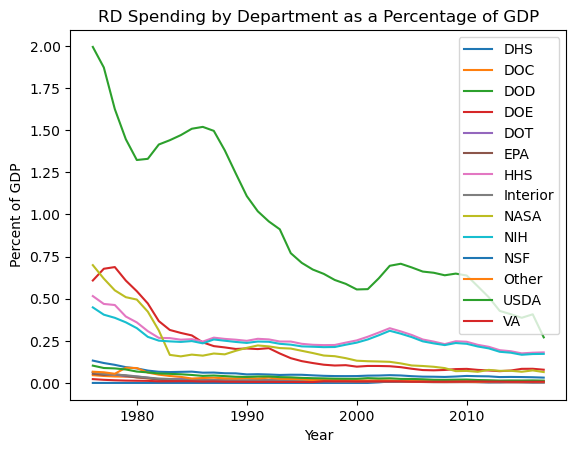

In [353]:
# I created a new column that gives the RD spending as a percentage of GDP 
df_fed_melted['percent_rd_of_gdp'] = (df_fed_melted['rd_spending'] / df_fed_melted['gdp']) * 100


# This loops all of the departments while seperating the dataset by each department
for dept, dept_info in df_fed_melted.groupby('department'):
    plt.plot(dept_info['year'], dept_info['percent_rd_of_gdp'], label=dept)

plt.xlabel('Year')
plt.ylabel('Percent of GDP')
plt.title('RD Spending by Department as a Percentage of GDP')

# This makes a key 
plt.legend()
plt.show()


### Code Breakdown 

This line graph shows research spending as a percentage of GDP for each department over time. I started by dividing the RD spending by the GDP and converting that into a percentage. I use groupby()to split the dataset into each department. The loop goes through each department’s data and plt.plot() draws a line for each department using year on the x-axis and percent_rd_of_gdp on the y-axis. This lets me compare how much each department spends relative to the size of the economy, not just in dollars. The earlier graphs led me to make this one because I wanted this graph to adjust for GDP and get a clearer comparison. It helped me see not just who spends the most, but who spends more relative to the size of the economy, which gives a more meaningful view of their investment. By using percent of GDP, I am asking how big the spending is relative to everything the country produces. This helps me compare across years more fairly. For example, if spending increases but GDP also grows, the percentage might stay the same, which shows that the investment level hasn’t really changed in importance. But if the percentage increases, it means that department is taking up more of the total economy, so its spending is becoming a bigger priority compared to everything else. So instead of just seeing who spends the most, I can see how significant that spending actually is, which makes the comparison more meaningful.

(210, 6)


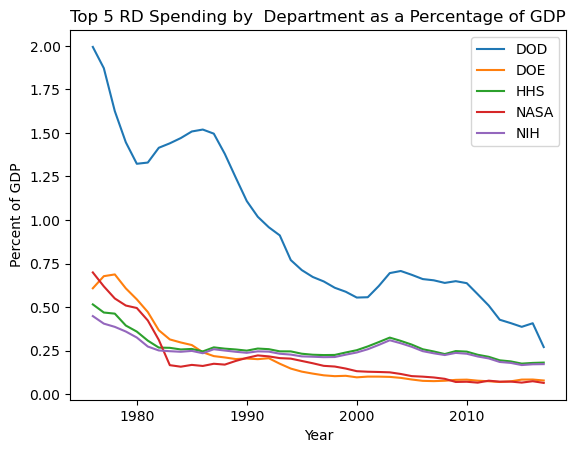

In [354]:
print(df_top_five.shape)

# I originally forgot to add the .index, so my graph had nothing on it. 
# Using index gives the department names so that the data can be matched with the departments. 
df_top_five = df_fed_melted[df_fed_melted['department'].isin(top_five_spending.index)]

for dept, dept_info in df_top_five.groupby('department'):
    plt.plot(dept_info['year'], dept_info['percent_rd_of_gdp'], label=dept)

plt.xlabel('Year')
plt.ylabel('Percent of GDP')
plt.title('Top 5 RD Spending by  Department as a Percentage of GDP')

plt.legend()
plt.show()


### Code Breakdown

This is the same line graph as before, but just with the top five departments. I did this to make the graph easier to read for me because it removes the lower spending departments that clutter the graph. I used top_five_spending.index to get the names of the top five departments. I originally forgot to include .index, which meant the filter didn’t match any department names and the graph showed nothing. Using .isin() filters the dataset so it only keeps rows for those top five departments. The graph is much clearer and makes it easier to compare their trends without too many overlapping lines. The DoD has a much higher spending compared to the other agencies, but all the agencies fail to keep up their RD spending in comparison to the GDP; they all decrease. This shows that their might not be a relationship between the economy and increasing research and development spending. 

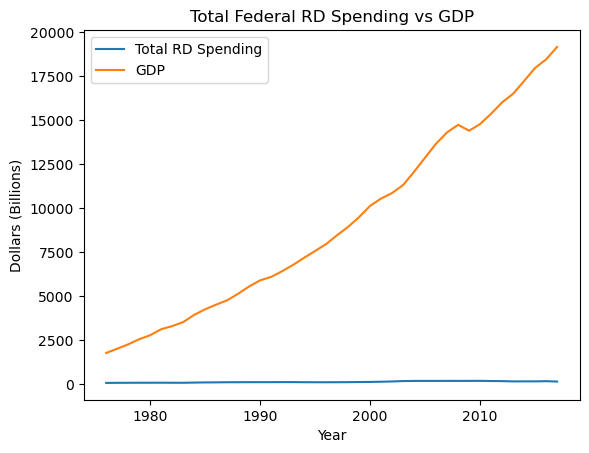

In [355]:
# Gets the total RD spending for each year
total_rd = df_fed_melted.groupby('year')['rd_spending'].sum()

# GDP per year which is the same for all departments
gdp = df_fed_melted.groupby('year')['gdp'].first()

# Convert both to billions for readability
total_rd_billions = total_rd / 1000000000
gdp_billions = gdp / 1000000000

# This creates the line graphs 
plt.plot(total_rd_billions.index, total_rd_billions.values, label='Total RD Spending')
plt.plot(gdp_billions.index, gdp_billions.values, label='GDP')

# Labels the axes
plt.xlabel('Year')
plt.ylabel('Dollars (Billions)')
plt.title('Total Federal RD Spending vs GDP')

# Creates key of lines 
plt.legend()
plt.show()

### Code Breakdown

The graph compared the total federal research spending to GDP over the years. I use groupby().sum() to add up all department spending for each year. This gave the total RD spending. I used the groupby().first() to get the GDP for each year, since the GDP value is the same across all departments, I only needed one value per year. I divide both by a billion to convert the numbers into billions so they are easier to read on the graph. This graph helps show how research spending grows compared to the overall economy and whether they increase at a similar pace or not. GDP is much larger so the graph shows that RD spending is only a small part of the overall economy. The graph isn't good for showing growth proportionate to each other, so I need to improve that. The RD spending line appears to be completely flat. 

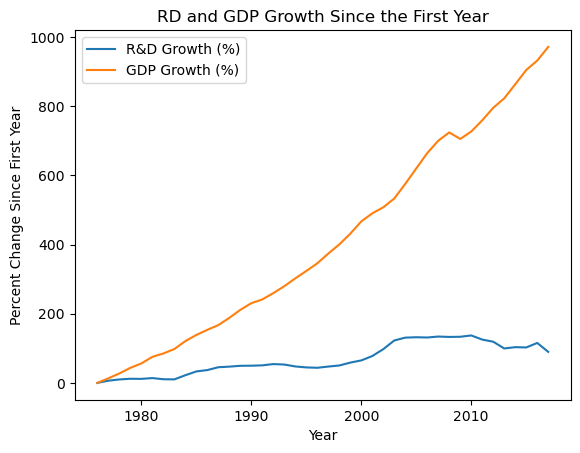

In [356]:
# Gets the total RD spending for each year
total_rd = df_fed_melted.groupby('year')['rd_spending'].sum()

# GDP per year which is the same for all departments
gdp = df_fed_melted.groupby('year')['gdp'].first()

# Change dollars to percent growth from the 1st year in the dataset instead of index
total_rd_growth = (total_rd / total_rd.iloc[0] - 1) * 100
gdp_growth = (gdp / gdp.iloc[0] - 1) * 100

# Makes the plots for the percent growth lines
plt.plot(total_rd_growth.index, total_rd_growth.values, label='R&D Growth (%)')
plt.plot(gdp_growth.index, gdp_growth.values, label='GDP Growth (%)')

# Labels the axes
plt.xlabel('Year')
plt.ylabel('Percent Change Since First Year')
plt.title('RD and GDP Growth Since the First Year')

# Creates key of lines
plt.legend()
plt.show()

### Code Breakdown 

I again compared how fast research spending and GDP grow over the years. I still group the data by year to get total RD spending and GDP. Instead of plotting the actual dollar amounts, I calculate percent growth. This shows how much each one has increased compared to the first year in the dataset. So if RD spending doubles, it would show as a 100% increase. This graph is an improvement from the previous one because the earlier graph compared the dollar amounts, which are very different in size because GDP is much larger than RD spending, so it’s harder to compare them directly. In this version, both lines start at zero percent, so I can clearly see which one is growing faster. This makes it easier to understand the relationship between them. The graph shows shows that federal RD spending has been rising slower than the economy. It has not even changed over 200%. 


## Pivot Table

In [357]:
# Used department as the index 
# seperate the columns by year
# Used aggregate function to sum RD spending for each department by year
pivot_table = pd.pivot_table(
    df_fed_melted, 
    values='rd_spending',
    index='department', 
    columns='year', 
    aggfunc='sum',
    fill_value=0)

# Convert values to billions for readability
pivot_table = pivot_table / 1000000000

# Show the pivot table
print("\nPivot Table (RD Spending in Billions by Department and Year):")
print(pivot_table.round(2))


Pivot Table (RD Spending in Billions by Department and Year):
year         1976   1977   1978   1979   1980   1981   1982   1983   1984  \
department                                                                  
DHS          0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
DOC          0.82   0.84   0.87   0.95   0.94   0.83   0.69   0.70   0.76   
DOD         35.70  37.97  37.02  37.17  37.01  41.74  46.89  51.01  58.14   
DOE         10.88  13.74  15.66  15.61  15.23  14.80  12.16  11.13  11.73   
DOT          1.14   1.10   1.16   1.00   1.05   0.98   0.70   0.80   1.02   
EPA          0.97   0.97   1.18   1.10   0.90   0.90   0.64   0.50   0.52   
HHS          9.23   9.51  10.53  10.13  10.04   9.64   8.86   9.42  10.14   
Interior     1.15   1.08   1.12   1.18   1.08   0.99   0.87   0.84   0.76   
NASA        12.51  12.55  12.52  13.08  13.84  13.28  10.32   5.89   6.23   
NIH          8.02   8.21   8.80   9.24   9.09   8.58   8.31   8.73   9.62   
NSF          

### Code Breakdown 

I created a pivot table to show the RD spending by department and year. Each row has a department and each column is a year. I used fill_value to replace the missing values with zero so the table would be complete. I divided all the values by a billion to make them easier to read. I rounded the values to two decimals. The pivot table is good for comparing spending between the different departments and between each year. The pivot table shows a each year broken down to help verify what the graphs are showing. 

## Final Takeaways 

The visualizations show that federal RD spending is highly concentrated among a few agencies. It grows over time, but does not increase at the same pace as the overall economy. 

The line graphs make it clear that RD spending is highly uneven across departments. The top five groups consistently accounts for the majority of investment, while the rest stay relatively flat and low over time. These top agencies are consistently the highest spenders. The gap between them and all other departments shows that RD funding is concentrated among a small group.

Including GDP puts the spending in perspective. Even when RD increases in dollar terms, it doesn’t necessarily take up a larger share of the economy. This suggests that RD isn’t being emphasized more over time. It could also mean the overall economy is growing faster, so the relative importance of RD stays the same. GDP is consistently much larger, and although both tend to increase over time, the gap between them remains substantial. 


